In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("water_quality_raw_uncleaned_100_records.csv")

In [3]:
df.head()

,Sample_ID,Date,State,City,Water_Source,pH,Turbidity_NTU,Dissolved_Oxygen,TDS_mg_L,Conductivity,Temperature_C,Water_Quality
0,1001,2025-01-01,Tamil Nadu,Chennai,Borewell,7.8,5.2,8.5,315.0,363,24.2,Poor
1,1002,2025-01-02,Telangana,Hyderabad,River,9.0,5.6,6.3,449.0,494,25.6,Moderate
2,1003,2025-01-03,Karnataka,NaN,River,5.5,5.5,5.7,383.0,613,30.8,Poor
3,1004,2025-01-04,Telangana,Hyderabad,tap,5.8,4.4,8.4,272.0,283,30.5,Good
4,1005,2025-01-05,Tamil Nadu,Madurai,river,8.0,3.6,8.8,169.0,450,26.0,Good


In [4]:
df.shape

(100, 12)

In [5]:
df.columns

Index(['Sample_ID', 'Date', 'State', 'City', 'Water_Source', 'pH',
       'Turbidity_NTU', 'Dissolved_Oxygen', 'TDS_mg_L', 'Conductivity',
       'Temperature_C', 'Water_Quality'],
      dtype='str')

In [6]:
df.isnull().sum()

Sample_ID            0
Date                 0
State                0
City                 8
Water_Source         1
pH                   1
Turbidity_NTU        0
Dissolved_Oxygen     0
TDS_mg_L             1
Conductivity         0
Temperature_C        1
Water_Quality       14
dtype: int64

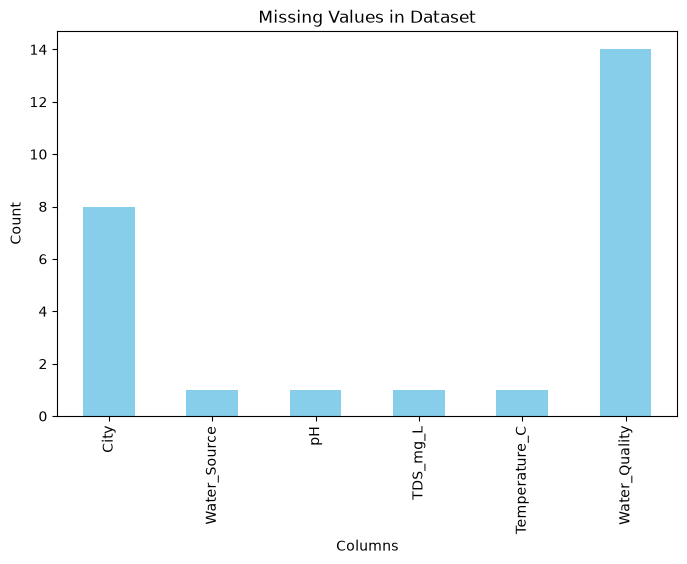

In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,5))

missing.plot(kind='bar', color='skyblue')

plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.show()

In [4]:
import pandas as pd

df = pd.read_csv("water_quality_raw_uncleaned_100_records.csv")

duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 3


In [5]:
df = df.drop_duplicates()

print("Total Rows After Removing Duplicates:", len(df))

Total Rows After Removing Duplicates: 97


In [6]:
df.isnull().sum()

Sample_ID            0
Date                 0
State                0
City                 6
Water_Source         1
pH                   1
Turbidity_NTU        0
Dissolved_Oxygen     0
TDS_mg_L             1
Conductivity         0
Temperature_C        1
Water_Quality       14
dtype: int64

In [12]:
df["City"] = df["City"].fillna("Unknown")
print(df["City"].isnull().sum())


0


In [14]:
df["Water_Source"] = df["Water_Source"].fillna("Unknown")
df["pH"] = df["pH"].fillna(df["pH"].mean())
df["TDS_mg_L"] = df["TDS_mg_L"].fillna(df["TDS_mg_L"].mean())
df["Temperature_C"] = df["Temperature_C"].fillna(df["Temperature_C"].mean())
df["Water_Quality"] = df["Water_Quality"].fillna("Unknown")
df.isnull().sum()

Sample_ID           0
Date                0
State               0
City                0
Water_Source        0
pH                  0
Turbidity_NTU       0
Dissolved_Oxygen    0
TDS_mg_L            0
Conductivity        0
Temperature_C       0
Water_Quality       0
dtype: int64

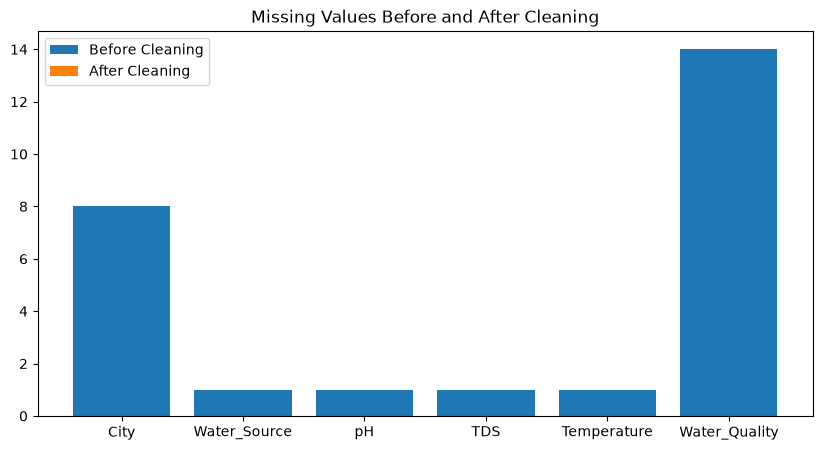

In [15]:
before = [8, 1, 1, 1, 1, 14]
after = [0, 0, 0, 0, 0, 0]

columns = ["City","Water_Source","pH","TDS","Temperature","Water_Quality"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(columns, before, label="Before Cleaning")
plt.bar(columns, after, label="After Cleaning")

plt.title("Missing Values Before and After Cleaning")
plt.legend()

plt.show()

In [16]:
text_columns = ["State", "City", "Water_Source", "Water_Quality"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Extra spaces removed successfully!")

Extra spaces removed successfully!


In [17]:
for col in text_columns:
    df[col] = df[col].str.title()

print("Text standardized successfully!")

Text standardized successfully!


In [20]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[us]


In [25]:
df[df["Date"].isnull()]

,Sample_ID,Date,State,City,Water_Source,pH,Turbidity_NTU,Dissolved_Oxygen,TDS_mg_L,Conductivity,Temperature_C,Water_Quality


In [23]:
df["Date"] = df["Date"].fillna(df["Date"].mode()[0])

In [24]:
df["Date"].isnull().sum()

np.int64(0)

In [26]:
df.to_csv("water_quality_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


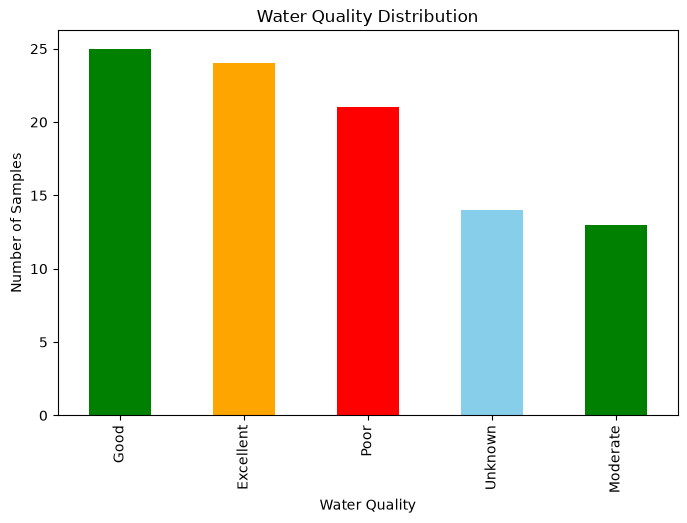

In [27]:
plt.figure(figsize=(8,5))

df["Water_Quality"].value_counts().plot(
    kind="bar",
    color=["green", "orange", "red", "skyblue"]
)

plt.title("Water Quality Distribution")
plt.xlabel("Water Quality")
plt.ylabel("Number of Samples")

plt.show()

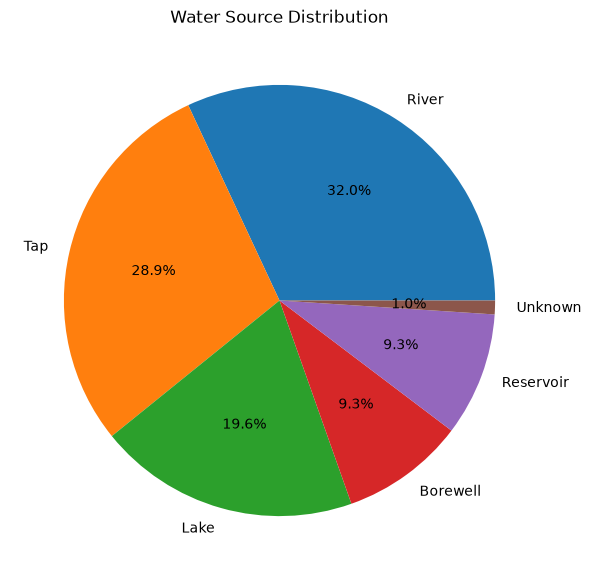

In [28]:
plt.figure(figsize=(7,7))

df["Water_Source"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Water Source Distribution")
plt.ylabel("")

plt.show()

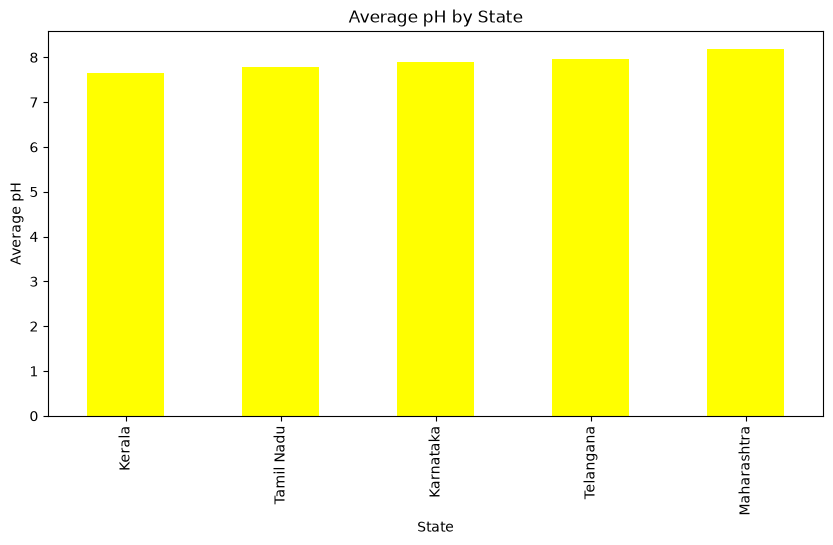

In [30]:
state_ph = df.groupby("State")["pH"].mean().sort_values()

plt.figure(figsize=(10,5))

state_ph.plot(
    kind="bar",
    color="Yellow"
)

plt.title("Average pH by State")
plt.xlabel("State")
plt.ylabel("Average pH")

plt.show()

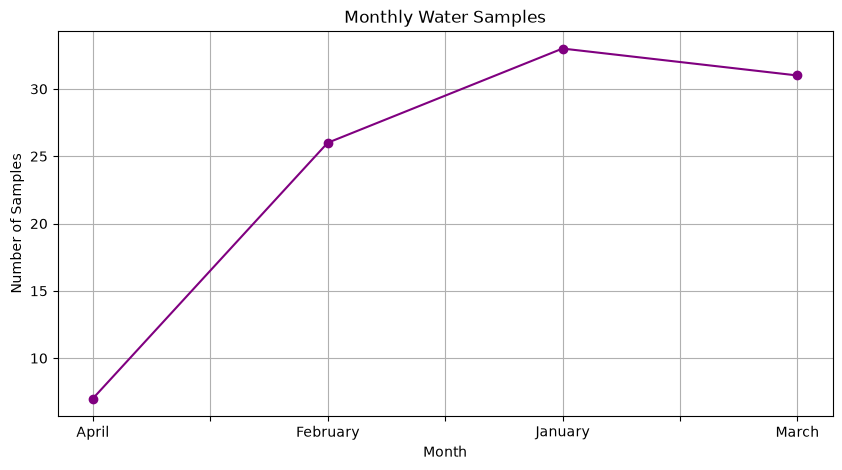

In [32]:
df["Month"] = df["Date"].dt.month_name()

monthly = df["Month"].value_counts().sort_index()

plt.figure(figsize=(10,5))

monthly.plot(
    kind="line",
    marker="o",
    color="purple"
)

plt.title("Monthly Water Samples")
plt.xlabel("Month")
plt.ylabel("Number of Samples")

plt.grid(True)

plt.show()

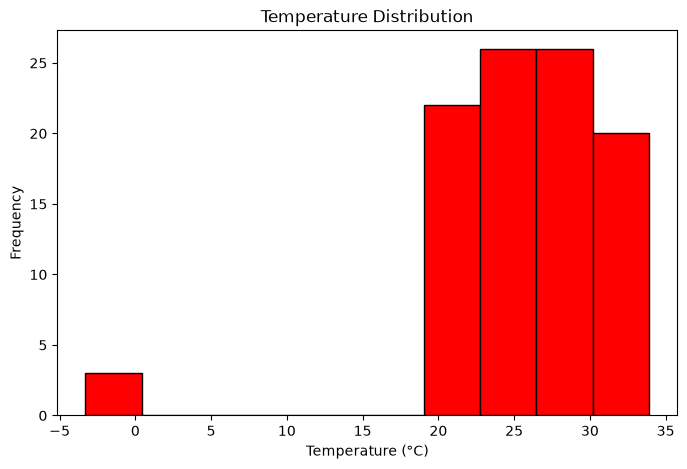

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Temperature_C"],
    bins=10,
    edgecolor="black",
    color="Red"
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

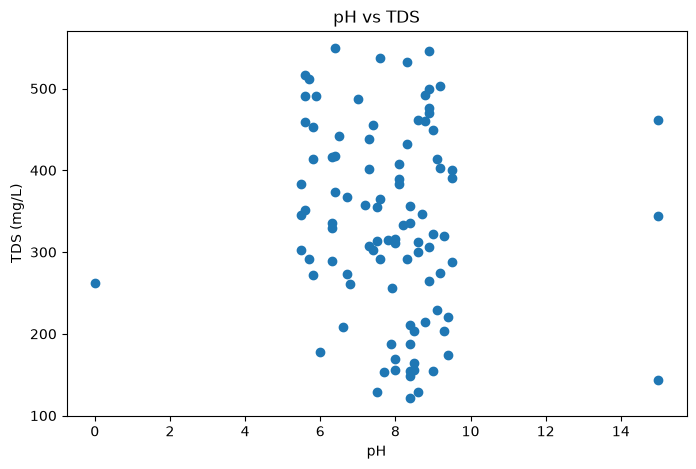

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["pH"],
    df["TDS_mg_L"],
)

plt.title("pH vs TDS")
plt.xlabel("pH")
plt.ylabel("TDS (mg/L)")

plt.show()

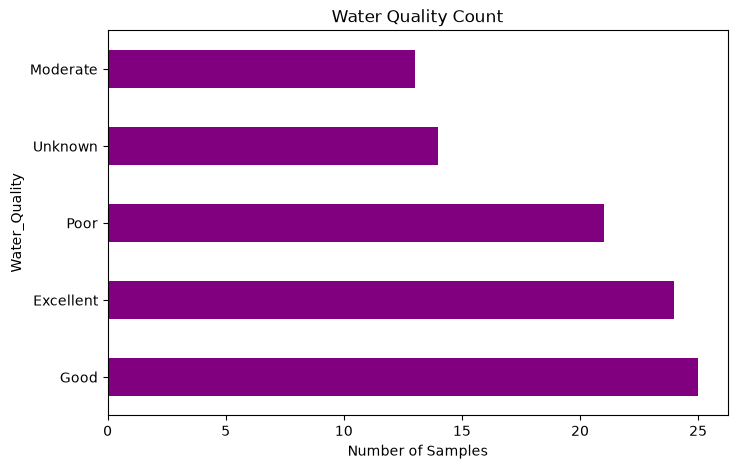

In [39]:
quality = df["Water_Quality"].value_counts()

plt.figure(figsize=(8,5))

quality.plot(
    kind="barh",
    color="purple"
)

plt.title("Water Quality Count")
plt.xlabel("Number of Samples")

plt.show()

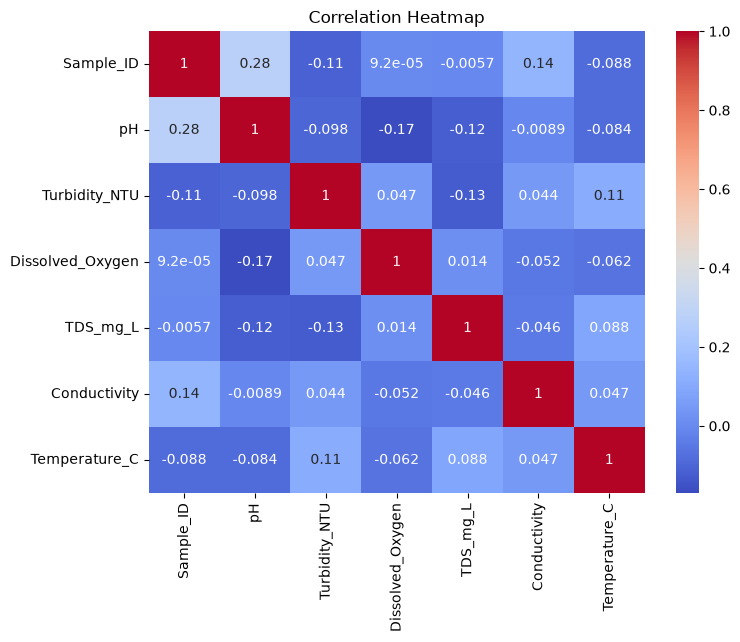

In [40]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()